In [40]:
# %%
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import StateSpace, bode

from datafile import datafile
from model_and_controller_equations.TCS_model_growth_equations import dydt, run_TCS_model

In [41]:
# %%
# =========================
# User settings
# =========================

# The two fils below have the same parameters, it just to demonstrate that you can have both csv and txt files processed.
param_csv = "parameters/guess.csv"
guess_file = "parameters/guess.txt"

t_i = 0.0 # Initial time, min
t_f = 960.0 # Final time, min    
t_inc = 1.0 # Time step, min 

input_mode = "dark"
setpoint = 0.0

t_disturb = 580.0 # 480 + the 100 minutes the cells grow under constant green light
#reduction_percents = np.array([20, 40, 60, 80], dtype=float) # If you want more discrete points
reduction_percents = np.linspace(20, 80, 100)

disturbed_state_name = "C"
output_state_name = "Pm"

normalize_output_by_operating_point = True

# For the Bode input scaling:
# "local"     -> 1% means 1% of the local operating-point value of C
# "reference" -> 1% means 1% of C(t_disturb)
percent_reference_basis = "local"

# Define the frequency range based on nominal time periods of disturbance
time_period_upper = 16*60   # minutes
time_period_lower = 1*60    # minutes
lower_w = 2 * np.pi / (time_period_upper) # rads/min
upper_w = 2 * np.pi / (time_period_lower) # rads/min
w = np.logspace(np.log10(lower_w), np.log10(upper_w), 200)

In [42]:
# %%
def simulate_baseline(DF):
    """Simulates the baseline trajectory without any disturbance"""
    params = DF["Initial_Parameters"]
    tspan = np.asarray(DF["tspan"], dtype=float)
    x0 = np.asarray(DF["Initial_Conditions"], dtype=float)
    input_mode = DF.get("input_mode", "dark")
    setpoint = DF.get("setpoint", 0.0)

    sol = run_TCS_model(
        x0=x0,
        time=tspan,
        params=params,
        setpoint=setpoint,
        input=input_mode,
        output="solve_ivp",
    )

    t = np.asarray(sol.t, dtype=float)
    x = np.asarray(sol.y, dtype=float).T
    return t, x


def massbalance_eqns(t, x, params, setpoint=0.0, input_mode="dark"):
    """The rhs of the ODE system, the function 'f' in the state-space formulation"""
    x = np.asarray(x, dtype=float)
    f = dydt(t, x, params, setpoint=setpoint, input=input_mode)
    return np.asarray(f, dtype=float)


def numerical_jacobian(params, x_op, input_mode="dark", setpoint=0.0):
    """Function to estimate the Jacobian of f numerically"""
    x0 = np.asarray(x_op, dtype=float)
    nx = x0.size
    A = np.zeros((nx, nx), dtype=float)
    t = 0.0

    for j in range(nx):
        h = max(1e-8, 1e-2 * abs(x0[j]))
        e = np.zeros(nx, dtype=float)
        e[j] = 1.0

        f_pp = massbalance_eqns(t, x0 + 2.0 * h * e, params, setpoint=setpoint, input_mode=input_mode)
        f_p = massbalance_eqns(t, x0 + 1.0 * h * e, params, setpoint=setpoint, input_mode=input_mode)
        f_m = massbalance_eqns(t, x0 - 1.0 * h * e, params, setpoint=setpoint, input_mode=input_mode)
        f_mm = massbalance_eqns(t, x0 - 2.0 * h * e, params, setpoint=setpoint, input_mode=input_mode)

        A[:, j] = (-f_pp + 8.0 * f_p - 8.0 * f_m + f_mm) / (12.0 * h)

    return A


def map_reduction_percents_to_times(t, state_traj, t_disturb, reduction_percents):
    """Function to obtain the operating time points from the baseline trajectory and disturbance %"""
    t = np.asarray(t, dtype=float)
    state_traj = np.asarray(state_traj, dtype=float)
    reduction_percents = np.atleast_1d(np.asarray(reduction_percents, dtype=float))

    state_ref = float(np.interp(t_disturb, t, state_traj))

    unique_vals, idx_unique = np.unique(state_traj, return_index=True)
    t_unique = t[idx_unique]

    out = []
    for pp in reduction_percents:
        state_post = state_ref * (1.0 - pp / 100.0)
        mapped_time = float(np.interp(state_post, unique_vals, t_unique))
        out.append(
            {
                "reduction_percent": float(pp),
                "state_ref": state_ref,
                "state_post": state_post,
                "mapped_time": mapped_time,
            }
        )
    return out


def output_matrix(state_names, output_state_name, x_op, normalize_output_by_operating_point=False):
    """Convert the output matrix such that the output is percentage deviation of Pm from the operating point"""
    n_states = len(state_names)
    Cmat = np.zeros((1, n_states), dtype=float)
    output_index = state_names.index(output_state_name)

    if normalize_output_by_operating_point:
        y0 = float(x_op[output_index])
        if y0 == 0.0:
            raise ValueError(
                f"Cannot normalize output {output_state_name} because its operating-point value is zero."
            )
        Cmat[0, output_index] = 100.0 / y0
    else:
        Cmat[0, output_index] = 1.0

    D = np.array([[0.0]], dtype=float)
    return Cmat, D, output_index


def local_linear_model_from_state_as_input(
    params,
    state_names,
    x_op,
    disturbed_state_name="C",
    output_state_name="Pm",
    input_mode="dark",
    setpoint=0.0,
    normalize_output_by_operating_point=False,
    percent_reference=None,
):
    """First constructs the reduced matrix A by removing the disturbance state C.
    Then converts the input matrix B such that the inputs have the units of percentages"""
    x_op = np.asarray(x_op, dtype=float)
    full_state_names = list(state_names)
    u_index = full_state_names.index(disturbed_state_name)

    A_full = numerical_jacobian(
        params=params,
        x_op=x_op,
        input_mode=input_mode,
        setpoint=setpoint,
    )

    keep = [i for i in range(len(full_state_names)) if i != u_index]
    reduced_state_names = [full_state_names[i] for i in keep]
    x_red = x_op[keep]

    A = A_full[np.ix_(keep, keep)]

    # IMPORTANT: use np.ix_ so this is shape (n_states_reduced, 1)
    dfdU = A_full[np.ix_(keep, [u_index])]

    if percent_reference is None:
        percent_reference = float(x_op[u_index])

    B = -(float(percent_reference) / 100.0) * dfdU
    B = np.asarray(B, dtype=float).reshape(len(keep), 1)

    Cmat, D, output_index_reduced = output_matrix(
        state_names=reduced_state_names,
        output_state_name=output_state_name,
        x_op=x_red,
        normalize_output_by_operating_point=normalize_output_by_operating_point,
    )

    Cmat = np.asarray(Cmat, dtype=float).reshape(1, len(keep))
    D = np.asarray(D, dtype=float).reshape(1, 1)

    return A, B, Cmat, D, reduced_state_names, output_index_reduced


In [43]:
# %%
DF = datafile(
    guess_file=guess_file,
    param_csv=param_csv,
    t_i=t_i,
    t_f=t_f,
    t_inc=t_inc,
    input_mode=input_mode,
    setpoint=setpoint,
)

state_names = list(DF["State_Names"])
params = DF["Initial_Parameters"]
n_states = len(state_names)

t_nl, x_nl = simulate_baseline(DF)

disturbed_index = state_names.index(disturbed_state_name)
out_index = state_names.index(output_state_name)

disturbed_traj = x_nl[:, disturbed_index]

mapping = map_reduction_percents_to_times(
    t=t_nl,
    state_traj=disturbed_traj,
    t_disturb=t_disturb,
    reduction_percents=reduction_percents,
)

## Optional printing statements
# print("Simulation complete.")
# print("States:", state_names)
# print(f"Reference disturbance time: {t_disturb:.3f} min")
# print(f"{disturbed_state_name}({t_disturb:.3f}) = {mapping[0]['state_ref']:.6g}")
# print("\nReduction percent to equivalent operating-point time mapping:")
# for m in mapping:
#     print(
#         f"  {m['reduction_percent']:.0f}% reduction -> "
#         f"post-disturbance {disturbed_state_name} = {m['state_post']:.6g}, "
#         f"mapped time = {m['mapped_time']:.3f} min"
#     )

In [44]:
## Frequency response analysis 

results = []
reference_value_at_disturbance = mapping[0]["state_ref"]

for m in mapping:
    reduction_percent = m["reduction_percent"]
    requested_time = m["mapped_time"]

    k = int(np.argmin(np.abs(t_nl - requested_time)))
    t_lin = float(t_nl[k])
    x_lin = x_nl[k, :].copy()

    if percent_reference_basis.lower() == "local":
        percent_reference = float(x_lin[disturbed_index])
    elif percent_reference_basis.lower() == "reference":
        percent_reference = float(reference_value_at_disturbance)
    else:
        raise ValueError("percent_reference_basis must be 'local' or 'reference'.")

    A, B, Cmat, D, reduced_state_names, reduced_output_index = local_linear_model_from_state_as_input(
        params=params,
        state_names=state_names,
        x_op=x_lin,
        disturbed_state_name=disturbed_state_name,
        output_state_name=output_state_name,
        input_mode=input_mode,
        setpoint=setpoint,
        normalize_output_by_operating_point=normalize_output_by_operating_point,
        percent_reference=percent_reference,
    )

    ## Optional printing statements
    # print("A shape:", A.shape)
    # print("B shape:", B.shape)
    # print("C shape:", Cmat.shape)
    # print("D shape:", D.shape)

    sys = StateSpace(A, B, Cmat, D)
    w_out, mag_db, phase_deg = bode(sys, w=w)
    mag_abs = 10.0 ** (mag_db / 20.0)

    results.append(
        {
            "reduction_percent": reduction_percent,
            "requested_time": float(requested_time),
            "k": k,
            "t_lin": t_lin,
            "x_lin": x_lin,
            "percent_reference": percent_reference,
            "A": A,
            "B": B,
            "Cmat": Cmat,
            "D": D,
            "reduced_state_names": reduced_state_names,
            "reduced_output_index": reduced_output_index,
            "w_out": w_out,
            "mag_db": mag_db,
            "mag_abs": mag_abs,
            "phase_deg": phase_deg,
        }
    )

## Optional summary printing
# print("\nLinearization summary:")
# for r in results:
#     print(
#         f"reduction = {r['reduction_percent']:.0f}%, "
#         f"mapped t = {r['requested_time']:.6g}, "
#         f"used t = {r['t_lin']:.6g}, "
#         f"{disturbed_state_name}_op = {r['x_lin'][disturbed_index]:.6g}, "
#         f"percent reference = {r['percent_reference']:.6g}"
#     )

/Users/harikrishnan/.local/lib/python3.8/site-packages/scipy/signal/_filter_design.py:1746: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  warnings.warn("Badly conditioned filter coefficients (numerator): the "


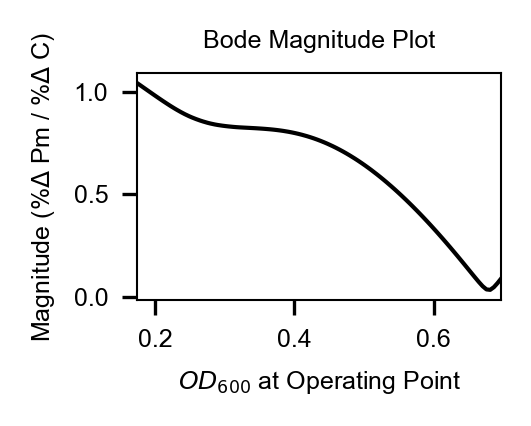

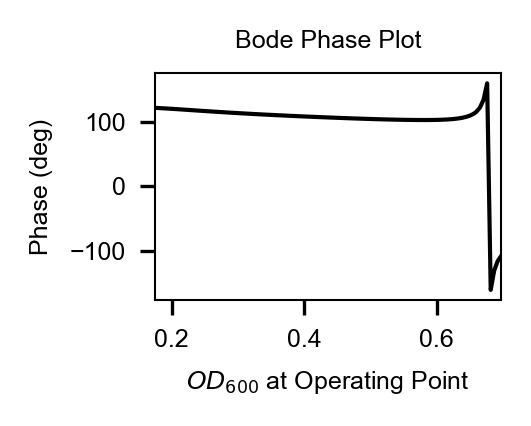

In [45]:
## Plot the Figures

# =========================
# User setting: period for Bode slice
# =========================
slice_period_min = 480  # <-- change this (in minutes)

# =========================
# Compute the slice frequency and extract magnitude/phase
# =========================
slice_w = 2 * np.pi / slice_period_min

# For each operating point, interpolate mag and phase at slice_w
slice_mag_abs = []
slice_phase_deg = []
slice_C_op = []

for r in results:
    slice_mag_abs.append(float(np.interp(slice_w, r["w_out"], r["mag_abs"])))
    slice_phase_deg.append(float(np.interp(slice_w, r["w_out"], r["phase_deg"])))
    slice_C_op.append(float(r["x_lin"][disturbed_index]/(8e8)))

slice_mag_abs = np.array(slice_mag_abs)
slice_phase_deg = np.array(slice_phase_deg)
slice_C_op = np.array(slice_C_op)

# %%
# =========================
# Plot 3: Magnitude vs C operating point
# =========================
bode_mag_cfg = {
    'figsize': (1.75, 1.4),
    'dpi': 300,
    'font_family': 'Arial',
    'base_fontsize': 6,
    'label_fontsize': 6,
    'title_fontsize': 6,
    'legend_fontsize': 6,
    'tick_fontsize': 6,
    'line_width': 1,
    'axis_linewidth': 0.5,
    'legend_loc': 'lower left',
    'grid_linewidth': 0.3,
    'handletextpad': 0.3,
    'handlelength': 1,
    'labelspacing': 0.25,
    'columnspacing': 0.3
}

plt.rcParams.update({
    'font.family': bode_mag_cfg['font_family'],
    'font.size': bode_mag_cfg['base_fontsize'],
    'axes.labelsize': bode_mag_cfg['label_fontsize'],
    'axes.titlesize': bode_mag_cfg['title_fontsize'],
    'legend.fontsize': bode_mag_cfg['legend_fontsize']
})

fig, ax = plt.subplots(figsize=bode_mag_cfg['figsize'], dpi=bode_mag_cfg['dpi'])

ax.plot(
    slice_C_op,
    slice_mag_abs,
    linewidth=bode_mag_cfg['line_width'],
    # color='#2171b5',
    color='k',
)
#ax.set_yscale('log')

ax.set_xlabel(r"$OD_{600}$ at Operating Point",
              fontsize=bode_mag_cfg['label_fontsize'])
if normalize_output_by_operating_point:
    ax.set_ylabel(f"Magnitude (%$\\Delta$ {output_state_name} / %$\\Delta$ {disturbed_state_name})",
                  fontsize=bode_mag_cfg['label_fontsize'])
else:
    ax.set_ylabel(f"Magnitude ({output_state_name} units / % {disturbed_state_name})",
                  fontsize=bode_mag_cfg['label_fontsize'])

ax.set_title(f"Bode Magnitude Plot",
             fontsize=bode_mag_cfg['title_fontsize'])
#ax.grid(True, which="both", linewidth=bode_mag_cfg['grid_linewidth'])

for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(bode_mag_cfg['axis_linewidth'])

ax.tick_params(axis='both', which='major', labelsize=bode_mag_cfg['tick_fontsize'])
ax.tick_params(axis='both', which='minor', labelsize=bode_mag_cfg['tick_fontsize'])

ax.set_xlim(min(slice_C_op), max(slice_C_op))

plt.tight_layout()
# plt.savefig(f'figures/bode_magnitude_vs_C_op_T{slice_period_min:.0f}min.svg',
#             format='svg', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

# %%
# =========================
# Plot 4: Phase vs C operating point
# =========================

bode_phase_cfg = {
    'figsize': (1.75, 1.4),
    'dpi': 300,
    'font_family': 'Arial',
    'base_fontsize': 6,
    'label_fontsize': 6,
    'title_fontsize': 6,
    'legend_fontsize': 6,
    'tick_fontsize': 6,
    'line_width': 1,
    'axis_linewidth': 0.5,
    'legend_loc': 'center right',
    'grid_linewidth': 0.3,
    'handletextpad': 0.3,
    'handlelength': 1.2,
    'labelspacing': 0.25
}

plt.rcParams.update({
    'font.family': bode_phase_cfg['font_family'],
    'font.size': bode_phase_cfg['base_fontsize'],
    'axes.labelsize': bode_phase_cfg['label_fontsize'],
    'axes.titlesize': bode_phase_cfg['title_fontsize'],
    'legend.fontsize': bode_phase_cfg['legend_fontsize']
})

fig, ax = plt.subplots(figsize=bode_phase_cfg['figsize'], dpi=bode_phase_cfg['dpi'])

ax.plot(
    slice_C_op,
    slice_phase_deg,
    linewidth=bode_phase_cfg['line_width'],
    # color='#2171b5',
    color='k',
)

ax.set_xlabel(r"$OD_{600}$ at Operating Point",
              fontsize=bode_phase_cfg['label_fontsize'])
ax.set_ylabel("Phase (deg)", fontsize=bode_phase_cfg['label_fontsize'])
ax.set_title(f"Bode Phase Plot",
             fontsize=bode_phase_cfg['title_fontsize'])
#ax.grid(True, linewidth=bode_phase_cfg['grid_linewidth'])

ax.set_xlim(min(slice_C_op), max(slice_C_op))

for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(bode_phase_cfg['axis_linewidth'])

ax.tick_params(axis='both', which='major', labelsize=bode_phase_cfg['tick_fontsize'])
ax.tick_params(axis='both', which='minor', labelsize=bode_phase_cfg['tick_fontsize'])

plt.tight_layout()
# plt.savefig(f'figures/bode_phase_vs_C_op_T{slice_period_min:.4g}min.svg',
#             format='svg', dpi=300, bbox_inches='tight', transparent=True)
plt.show()